# **Práctica 3.2: Aprendizaje Automático (Regresión)**

<hr>

## **1. Introducción**

En la práctica anterior nos centramos en la resolución de problemas donde pretendíamos, a partir de una entrada, predecir una clase (clasificación). 

Para finalizar con el diagrama del *aprendizaje automático*, más concretamente con la rama del *aprendizaje supervisado*, aún nos quedaría por ver los problemas de **regresión**.

<center><img src="https://i.imgur.com/CN1RVmy.png" alt="diagram" width="1000"/></center>

Como sabes, en un problema de regresión buscamos predecir uno o varios **valores numéricos**. Al igual que en la clasificación, para poder resolver problemas de aprendizaje supervisado de regresión también vamos a necesitar **datos etiquetados**, es decir, datos donde ya conocemos, para una entrada dada, la salida esperada o etiqueta correcta. 

Estos datos serán los que utilice el modelo para intentar aprender esa *fórmula desconocida* durante el entrenamiento.

### **Objetivo**
En esta práctica aprenderás a resolver problemas de regresión utilizando diferentes modelos así como a evaluar su rendimiento. 


<hr>

## **2. Ejercicio 1**

Se nos solicita realizar la siguiente tarea:

> Crear un modelo que, dado el tiempo en el primer sector `Sector1Time` sea capaz de predecir el tiempo total de la vuelta `LapTime`.    

Vamos a cargar de nuevo nuestros datos y a generar el conjunto necesario para resolver el problema.


In [172]:
import pandas as pd

seed = 2533

data = pd.read_pickle("https://raw.githubusercontent.com/AIC-Uniovi/Sistemas-Inteligentes/refs/heads/main/datasets/f1_23_monaco.pkl")

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Crea un gráfico de dispersión para analizar la relación entre ambas variables.
</div>

Text(0.5, 1.0, 'Relación entre el tiempo en el segundo sector y la velocidad de vuelta')

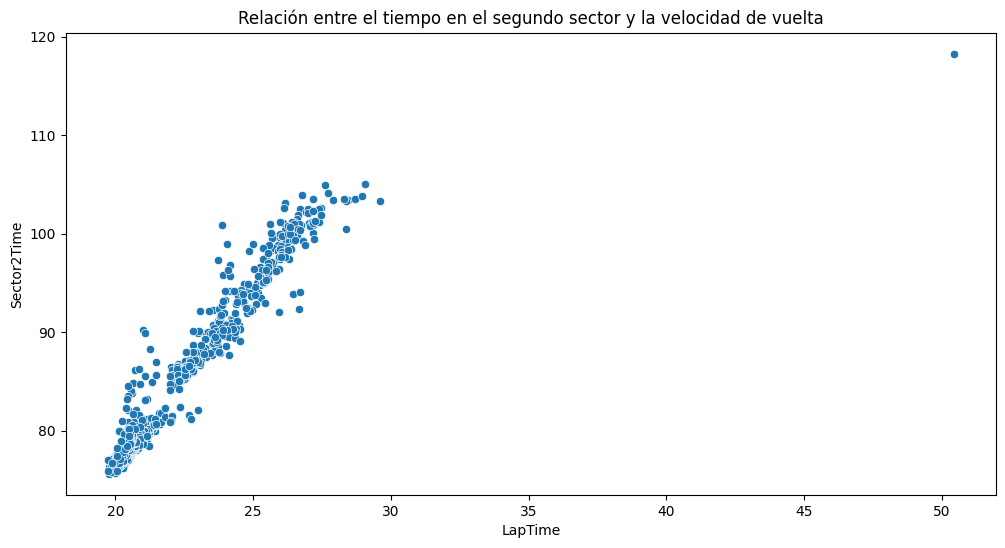

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

data["Sector1Time"]=data["Sector1Time"].dt.total_seconds()
data["LapTime"]= data["LapTime"].dt.total_seconds()
# Tu código aquí
fig_size=(12,6)
plt.figure(figsize=fig_size); # Tamaño del plot
the_plot = sns.scatterplot(data=data, x=data["Sector1Time"], y=data["LapTime"])
the_plot.set_ylabel("Sector2Time")
the_plot.set_xlabel("LapTime")
the_plot.set_title("Relación entre el tiempo en el segundo sector y la velocidad de vuelta")


<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Elimina el <i>outlier</i> del dataframe y genera el gráfico de nuevo. Dado el nuevo gráfico ¿dirías que la relación entre las variables es <strong>lineal</strong> o <strong>no lineal</strong>?
</div>

Text(0.5, 1.0, 'Relación entre el tiempo en el segundo sector y la velocidad de vuelta')

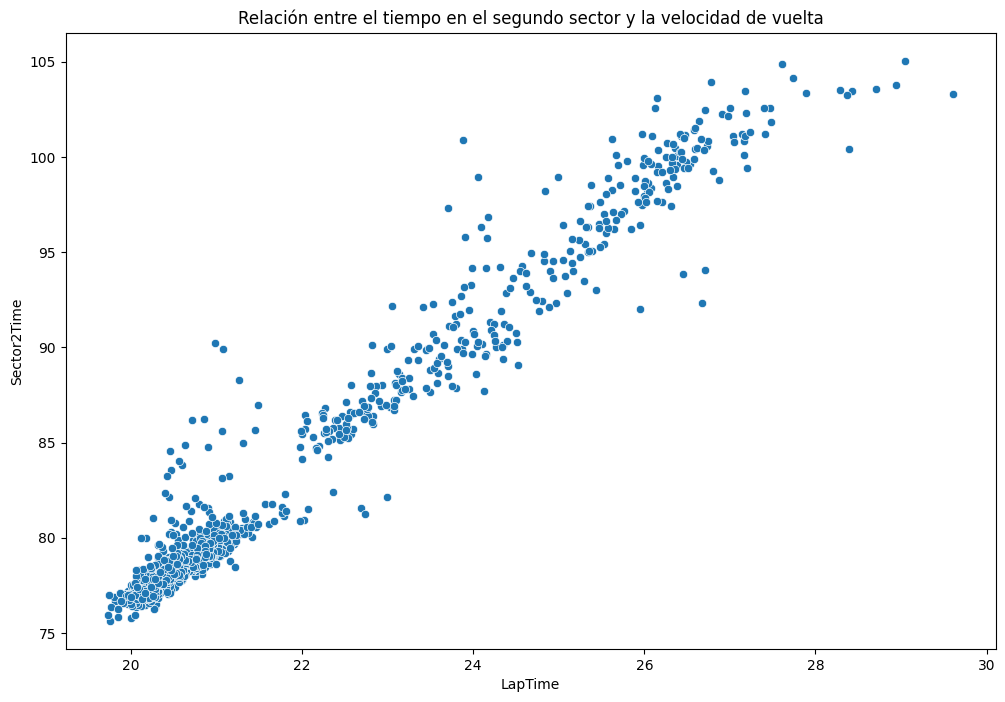

In [174]:
# Tu código aquí
data=data.loc[data["Sector1Time"]<32]
fig_size= (12,8)
plt.figure(figsize=fig_size); # Tamaño del plot
the_plot = sns.scatterplot(data=data, x=data["Sector1Time"], y=data["LapTime"])
the_plot.set_ylabel("Sector2Time")
the_plot.set_xlabel("LapTime")
the_plot.set_title("Relación entre el tiempo en el segundo sector y la velocidad de vuelta")

En función del tipo de relación habrá que seleccionar unos modelos de regresión u otros. 

<div class="alert alert-block alert-warning">
    No siempre podemos analizar visualmente como es esta relación, en este caso si por que solo tenemos dos variables, pero normalmente esto no será posible.
</div>

### **Datasets**

Independientemente del modelo elegido, al igual que en la parte de clasificación será necesario crear un dataset etiquetado (con X e Y) y dividido en entrenamiento y test.

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Crea el DataFrame <code>data_sector2lap</code> con las columnas necesarias para resolver este problema. Transforma las columnas de timedelta a float mediante <code>data["columnname"].dt.total_seconds()</code> .Divide en entrenamiento y test (80/20), posteriormente <b>estandariza</b> las X.
    <hr>
    Cuando la X solo tiene una columna, es necesario utilizar dobles corchetes (<code>data[["nombrecolumna"]]</code> y no <code>data["nombrecolumna"]</code>) para que funcione correctamente el <code>StandardScaler()</code>.
</div>

In [175]:
# Tu código aquí
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data_sector2lap= data[["Sector2Time", "LapTime"]]
data_sector2lap_train,data_sector2lap_test = train_test_split(data_sector2lap,test_size=0.2, random_state=seed)

X_train = data_sector2lap_train[["Sector2Time"]]
Y_train= data_sector2lap_train["LapTime"]

X_test = data_sector2lap_test[["Sector2Time"]]
Y_test = data_sector2lap_test["LapTime"]

standarizer = StandardScaler()
X_train = standarizer.fit_transform(X_train)
X_test = standarizer.transform(X_test)




Vamos a verificar los datos de entrenamiento y de test con el siguiente gráfico:

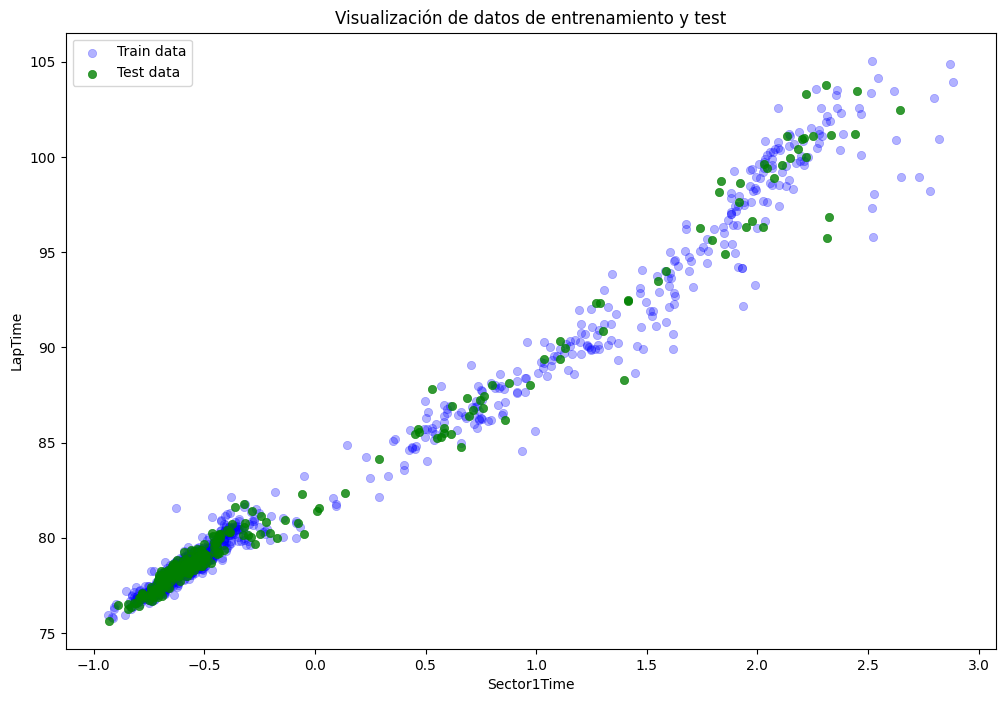

In [176]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=X_train.flatten(), y=Y_train, color=('blue', 0.3), edgecolors=None, label='Train data')
plot = sns.scatterplot(x=X_test.flatten(), y=Y_test, color=('green', 0.8), edgecolors=None, label='Test data')
plot.set_xlabel("Sector1Time")
plot.set_ylabel("LapTime")
plot.set_title("Visualización de datos de entrenamiento y test")
plt.show()

### **Baseline y métricas**
Una vez creados y preprocesados los conjuntos ya podemos pasar a resolver el problema. Al igual que en los problemas de clasificación, para regresión también existen una serie de **baselines**.

El más utilizado es el modelo `Media` que simplemente retorna siempre la media de las $Y$ del conjunto de entrenamiento. También existen versiones que hacen lo propio con la mediana o con cuantiles predefinidos.

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Crea y entrena un baseline "Media" haciendo uso de la clase <a href = "https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html"><code>DummyRegressor()</code></a> de <i>scikit-learn</i>. Guarda el modelo en la variable <code>baseline_media</code>.
</div>

In [177]:
# Tu código aquí
from sklearn.dummy import DummyRegressor

baseline_media = DummyRegressor(strategy="mean")
baseline_media.fit(X_train,Y_train)

,strategy,'mean'
,constant,None
,quantile,None


Una vez tenemos el modelo, como trabajamos en 2D podemos representarlo en el gráfico anterior.

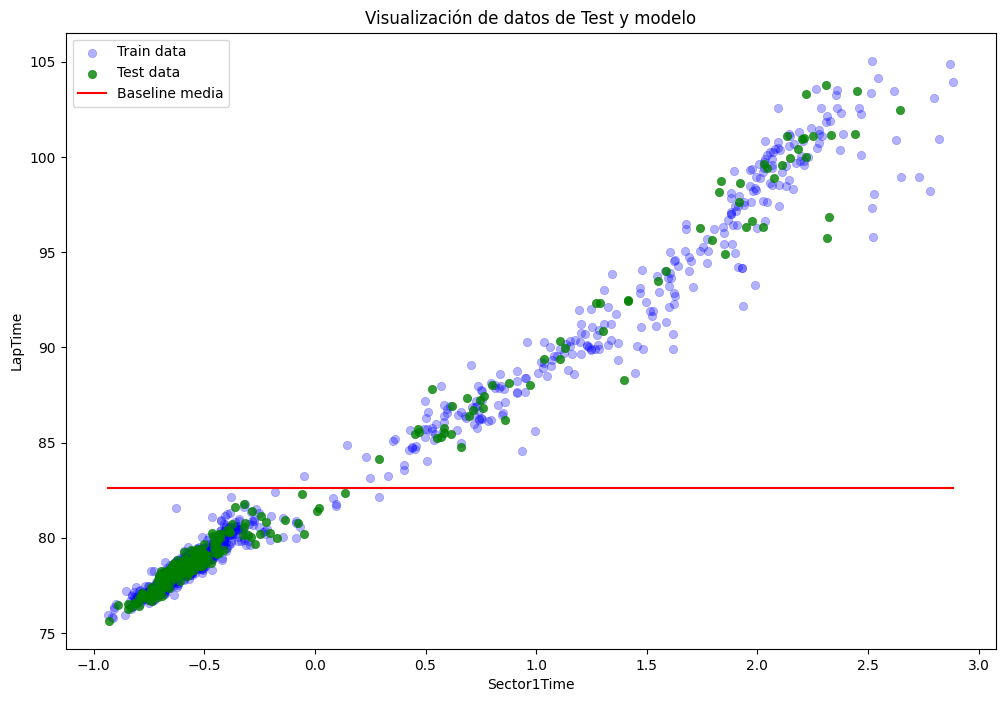

In [178]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=X_train.flatten(), y=Y_train, color=('blue', 0.3), edgecolors=None, label='Train data')
sns.scatterplot(x=X_test.flatten(), y=Y_test, color=('green', 0.8), edgecolors=None, label='Test data')
plot = sns.lineplot(x=X_train.flatten(), y=baseline_media.predict(X_train), color="red", label="Baseline media")
plot.set_xlabel("Sector1Time")
plot.set_ylabel("LapTime")
plot.set_title("Visualización de datos de Test y modelo")
plt.show()

Como ves, el baseline no se ajusta nada bien al los datos de entrenamiento, por lo que su rendimiento dejará mucho que desear.

Para cuantificar la capacidad de predicción del modelo vamos, al igual que en clasificación, a obtener unas **métricas**. 

<div class="alert alert-block alert-warning">
    No es posible utilizar las métricas de clasificación en problemas de regresión. Las primeras están pensadas para trabajar con probabilidades (número entre 0 y 1) y las de regresión para números reales (entre -inf e inf).
</div>

Para este tipo de problemas se suelen utilizar 2 métricas principalmente, las cuales se limitan a calcular **las diferencias entre los valores reales $Y$ y los valores predichos por el modelo $\hat{Y}$** estas son:
* **MAE:** Error absoluto medio, implementado en el método [`mean_absolute_error(Y_test, Y_pred)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html#sklearn.metrics.mean_absolute_error).

* **MSE:** Error cuadrático medio, implementado en el método [`mean_squared_error(Y_test, Y_pred)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html#sklearn.metrics.mean_squared_error).

* **$R^2$:** Coeficiente de determinación, implementado en el método [`r2_score(Y_test, Y_pred)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html).



<div class="alert alert-block alert-warning">
    <strong>Como el <i>MAE</i> y el <i>MSE</i> miden errores, son mejores cuanto menor es su valor. El <i>Coeficiente de determinación</i>, por el contrario, es mejor cuanto más próximo a 1 se encuentra.</strong>
</div>

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Obtén las métricas anteriores para el baseline en el conjunto de <i>entrenamiento</i> y <i>test</i>.
</div>

In [179]:
# Tu código aquí
from sklearn import metrics

Y_train_pred= baseline_media.predict(X_train)
mae= metrics.mean_absolute_error(Y_train, Y_train_pred)
mse= metrics.mean_squared_error(Y_train, Y_train_pred)
r2= metrics.r2_score(Y_train, Y_train_pred)

print(f"mae train: {mae}")
print(f"mse train: {mse}")
print(f"r2 train: {r2}")

Y_test_pred= baseline_media.predict(X_test)
mae= metrics.mean_absolute_error(Y_test, Y_test_pred)
mse= metrics.mean_squared_error(Y_test, Y_test_pred)
r2= metrics.r2_score(Y_test, Y_test_pred)

print(f"mae test: {mae}")
print(f"mse test: {mse}")
print(f"r2 test: {r2}")

mae train: 5.945402309799259
mse train: 54.16377531940761
r2 train: 0.0
mae test: 5.6741410820789575
mse test: 51.03874148105154
r2 test: -0.002479871777153031


### **Otros modelos**

Como verás, los resultados dejan mucho que desear (como se podía prever en la gráfica anterior) por tanto es necesario utilizar modelos más complejos que hagan uso de los datos de entrada. 

En esta práctica veremos los siguientes:

* **Regresión lineal:** Aprende relaciones lineales entre las variables de entrada y de salida.
* **Regresión polinomial:** Extiende la regresión lineal al permitir relaciones no lineales mediante el uso de polinomios.
* **K-Nearest Neighbors:** Algoritmo de regresión que predice el valor de una instancia basándose en el promedio de los valores de sus $k$ vecinos más cercanos.
* **Arboles de decisión:** Modelo de regresión que crea un árbol para predecir un valor basado en las características de los datos (entradas).
* **SVR:** Versión para regresión del SVM. Al igual que en clasificación, sin funciones kernel solo es capaz de aprender relaciones lineales. Busca que la mayoría de ejemplos se encuentren dentro del $e$-tubo.

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Entrena un modelo de <i>Regresión Lineal</i> (<code>model_linear</code>) y evalúa su rendimiento en <i>entrenamiento</i> y <i>test</i>.
</div>

In [180]:
# Tu código aquí
from sklearn.linear_model import LinearRegression

model_linear= LinearRegression()
model_linear.fit(X_train,Y_train)

Y_train_pred= model_linear.predict(X_train)
mae= metrics.mean_absolute_error(Y_train, Y_train_pred)
mse= metrics.mean_squared_error(Y_train, Y_train_pred)
r2= metrics.r2_score(Y_train, Y_train_pred)

print(f"mae train: {mae}")
print(f"mse train: {mse}")
print(f"r2 train: {r2}")

Y_test_pred= model_linear.predict(X_test)
mae= metrics.mean_absolute_error(Y_test, Y_test_pred)
mse= metrics.mean_squared_error(Y_test, Y_test_pred)
r2= metrics.r2_score(Y_test, Y_test_pred)

print(f"mae test: {mae}")
print(f"mse test: {mse}")
print(f"r2 test: {r2}")

mae train: 0.651018034393364
mse train: 1.0841365855857634
r2 train: 0.9799841023046763
mae test: 0.6184200947175325
mse test: 0.9687396106241846
r2 test: 0.9809724547968228


Para verificar el modelo aprendido, dibujaremos de nuevo el modelo resultante.

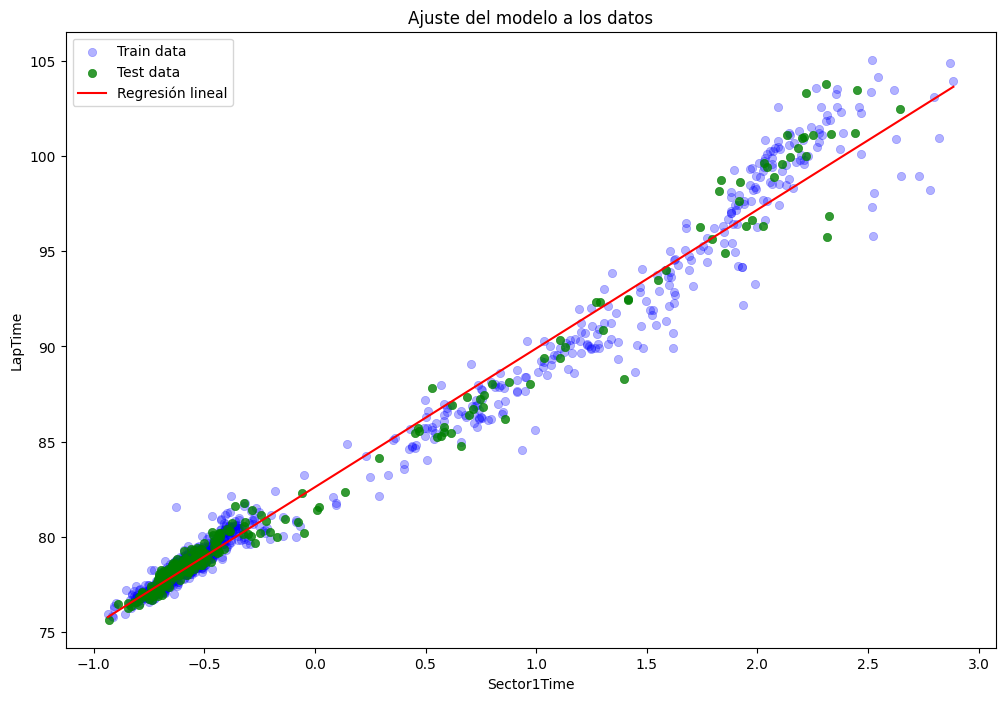

In [181]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=X_train.flatten(), y=Y_train, color=('blue', 0.3), edgecolors=None, label='Train data')
sns.scatterplot(x=X_test.flatten(), y=Y_test, color=('green', 0.8), edgecolors=None, label='Test data')
plot = sns.lineplot(x=X_train.flatten(), y=model_linear.predict(X_train), color="red", label="Regresión lineal")
plot.set_xlabel("Sector1Time")
plot.set_ylabel("LapTime")
plot.set_title("Ajuste del modelo a los datos")
plt.show()

Como ves, este modelo se ajusta mucho mejor a los datos de entrenamiento y por ende funciona mejor con el conjunto de test.

#### **¿Es posible mejorar aún más los resultados?**

Vamos a intentar ahora resolver el problema mediante un método no lineal: **Regresión polinómica**.

Este modelo no tiene una clase como tal en *Scikit-learn*, pero podemos usar `PolynomialFeatures`. Esta clase transforma nuestros datos en *features* polinómicas. 

Por ejemplo, si tenemos una sola *feature* $x$ y elegimos un grado 3, `PolynomialFeatures` creará dos *features* nuevas, $x^3$, $x^2$ y $x$. 

Esto nos permite ajustar un modelo lineal a los datos transformados, lo que equivale a ajustar un modelo polinómico a los datos originales.

In [182]:
from sklearn.preprocessing import PolynomialFeatures

# Transformar las características en características polinomiales
poly = PolynomialFeatures(degree=3) 
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Ajustar el modelo de regresión lineal a las características polinomiales
model_poly = LinearRegression()
model_poly.fit(X_train_poly, Y_train)

# Evaluar el modelo en el conjunto de entrenamiento
print(metrics.mean_absolute_error(Y_train, model_poly.predict(X_train_poly)))
print(metrics.mean_squared_error(Y_train, model_poly.predict(X_train_poly)))
print(metrics.r2_score(Y_train, model_poly.predict(X_train_poly)))
print("----")

# Evaluar el modelo en el conjunto de prueba
print(metrics.mean_absolute_error(Y_test, model_poly.predict(X_test_poly)))
print(metrics.mean_squared_error(Y_test, model_poly.predict(X_test_poly)))
print(metrics.r2_score(Y_test, model_poly.predict(X_test_poly)))

0.6037764203178886
0.9291284550544278
0.9828459436297545
----
0.5539941819805217
0.7709195180153382
0.9848579475679775


Para verificar el modelo aprendido, dibujaremos de nuevo el modelo resultante.

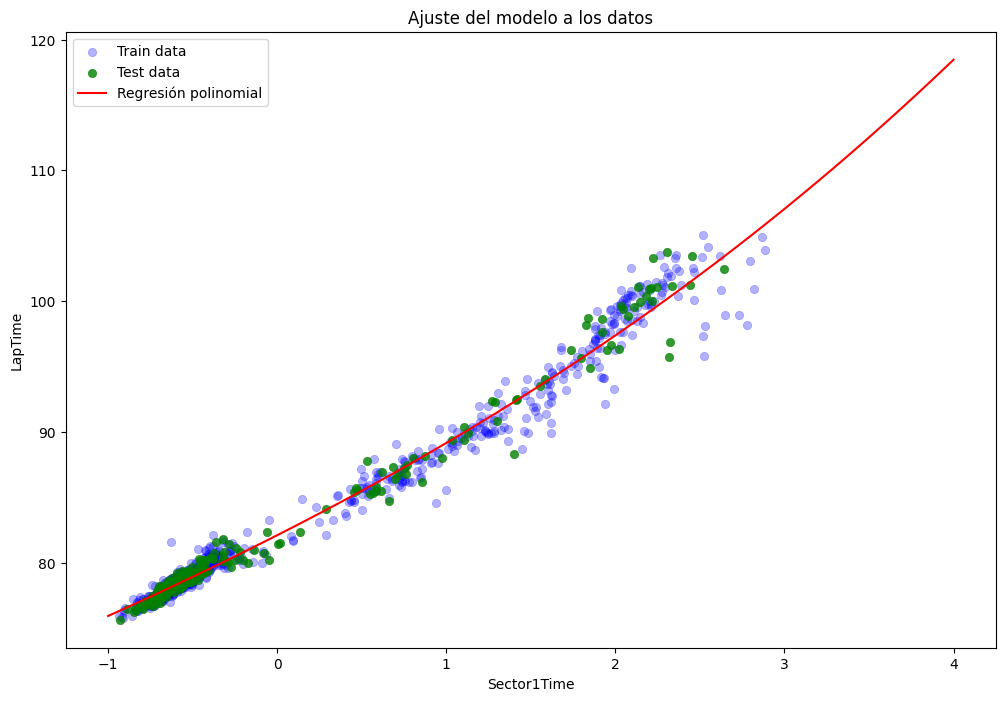

In [183]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=X_train.flatten(), y=Y_train, color=('blue', 0.3), edgecolors=None, label='Train data')
sns.scatterplot(x=X_test.flatten(), y=Y_test, color=('green', 0.8), edgecolors=None, label='Test data')

X_range = [[i/10] for i in range(-10, 41)]
X_range_poly = poly.transform(X_range)
y_range_pred = model_poly.predict(X_range_poly)
plot = sns.lineplot(x=[x[0] for x in X_range], y=y_range_pred, color="red", label="Regresión polinomial")

plot.set_xlabel("Sector1Time")
plot.set_ylabel("LapTime")
plot.set_title("Ajuste del modelo a los datos")
plt.show()

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Entrena evalúa y dibuja un modelo de <i>Regresión polinomial</i> (<code>model_poli_2</code>) de grado 10. Crea nuevas variables para evitar sobrescribir el modelo anterior.
</div>

In [184]:
# Tu código aquí
# Transformar las características en características polinomiales
model_poly_2 = PolynomialFeatures(degree=10) 
X_train_poly_2 = model_poly_2.fit_transform(X_train)
X_test_poly_2 = model_poly_2.transform(X_test)

# Ajustar el modelo de regresión lineal a las características polinomiales
model_poly_2 = LinearRegression()
model_poly_2.fit(X_train_poly_2, Y_train)

# Evaluar el modelo en el conjunto de entrenamiento
print(metrics.mean_absolute_error(Y_train, model_poly_2.predict(X_train_poly_2)))
print(metrics.mean_squared_error(Y_train, model_poly_2.predict(X_train_poly_2)))
print(metrics.r2_score(Y_train, model_poly_2.predict(X_train_poly_2)))
print("----")

# Evaluar el modelo en el conjunto de prueba
print(metrics.mean_absolute_error(Y_test, model_poly_2.predict(X_test_poly_2)))
print(metrics.mean_squared_error(Y_test, model_poly_2.predict(X_test_poly_2)))
print(metrics.r2_score(Y_test, model_poly_2.predict(X_test_poly_2)))

0.4950477869652956
0.6193864684012665
0.9885645624820518
----
0.5000125556499063
0.7095112060024092
0.9860641018532597


Como ves, si intentamos crear un modelo que se ajuste muy bien a los datos de entrenamiento caemos en el llamado **sobreajuste** u overfitting.

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Entrena y evalúa los modelos restantes (<i>K-Nearest Neighbors</i>, <i>Árboles de decisión</i> y <i>SVR</i>) utilizando la siguiente función.
</div>

In [185]:
def evaluate_model(model, X_train, Y_train, X_test, Y_test, model_name):
    mae_train = metrics.mean_absolute_error(Y_train, model.predict(X_train))
    mse_train = metrics.mean_squared_error(Y_train, model.predict(X_train))
    r2_train = metrics.r2_score(Y_train, model.predict(X_train))
    mae_test = metrics.mean_absolute_error(Y_test, model.predict(X_test))
    mse_test = metrics.mean_squared_error(Y_test, model.predict(X_test))
    r2_test = metrics.r2_score(Y_test, model.predict(X_test))
    results = [model_name, mae_train, mse_train, r2_train, mae_test, mse_test, r2_test]
    return results

all_results = []

# Baseline
results_base = evaluate_model(baseline_media, X_train, Y_train, X_test, Y_test, "Baseline")
all_results.append(results_base)

# Lineal 
results_lineal = evaluate_model(model_linear, X_train, Y_train, X_test, Y_test, "Lineal")
all_results.append(results_lineal)

# Polinomial
results_poly = evaluate_model(model_poly, X_train_poly, Y_train, X_test_poly, Y_test, "Polinomial (3)")
all_results.append(results_poly)

# Tu código aquí
# Los modelos anteriores ya están entrenados, recuerda entrenar los nuevos antes de pasarlos a la función
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
# KNN
knn= NearestNeighbors()
knn.fit(X_train,Y_train)
# Árboles
tree= DecisionTreeRegressor()
tree.fit(X_train,Y_train)
# SVR
svr = SVR()
svr.fit(X_train,Y_train)

# Imprimir el dataframe resultante
multi_index = pd.MultiIndex.from_tuples([ ("Modelo", "Nombre"), ("Train", "MAE"), ("Train", "MSE"), ("Train", "R^2"), ("Test", "MAE"), ("Test", "MSE"), ("Test", "R^2")])    
all_results = pd.DataFrame(all_results, columns=multi_index)
all_results

Modelo     Train                           Test             \
           Nombre       MAE        MSE       R^2       MAE        MSE   
0        Baseline  5.945402  54.163775  0.000000  5.674141  51.038741   
1          Lineal  0.651018   1.084137  0.979984  0.618420   0.968740   
2  Polinomial (3)  0.603776   0.929128  0.982846  0.553994   0.770920   

             
        R^2  
0 -0.002480  
1  0.980972  
2  0.984858

<hr>

## **3. Ejercicio 2**

Se nos solicita realizar la siguiente tarea:

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Crea un modelo capaz de predecir, a partir de <i>LapTime</i> a parir de <i>SpeedI1</i>, <i>SpeedI2</i>, <i>SpeedFL</i>, <i>SpeedST</i> y <i>TyreLife</i>. ¿Cuál es el modelo con mejores resultados?
</div>

In [ ]:
# Tu código aquí

data= data.dropna()
data_laptime= data[["LapTime","SpeedI1","SpeedI2", "SpeedFL", "SpeedST","TyreLife"]]

data_laptime_train, data_laptime_test = train_test_split(data_laptime, test_size=0.2, random_state=seed)

X_train = data_laptime_train[["SpeedI1", "SpeedI2", "SpeedFL", "SpeedST", "TyreLife"]]
Y_train = data_laptime_train["LapTime"]

X_test = data_laptime_test[["SpeedI1", "SpeedI2", "SpeedFL", "SpeedST", "TyreLife"]]
Y_test = data_laptime_test["LapTime"]

X_train = standarizer.fit_transform(X_train)
X_test = standarizer.transform(X_test)

def evaluate_model(model, X_train, Y_train, X_test, Y_test, model_name):
    mae_train = metrics.mean_absolute_error(Y_train, model.predict(X_train))
    mse_train = metrics.mean_squared_error(Y_train, model.predict(X_train))
    r2_train = metrics.r2_score(Y_train, model.predict(X_train))
    mae_test = metrics.mean_absolute_error(Y_test, model.predict(X_test))
    mse_test = metrics.mean_squared_error(Y_test, model.predict(X_test))
    r2_test = metrics.r2_score(Y_test, model.predict(X_test))
    results = [model_name, mae_train, mse_train, r2_train, mae_test, mse_test, r2_test]
    return results

all_results = []

# Baseline
base =LinearRegression()
base.fit(X_train, Y_train)
results_base = evaluate_model(baseline_media, X_train, Y_train, X_test, Y_test, "Baseline")
all_results.append(results_base)

# Lineal 
model_linear = LinearRegression()
model_linear.fit(X_train, Y_train)
results_lineal = evaluate_model(model_linear, X_train, Y_train, X_test, Y_test, "Lineal")
all_results.append(results_lineal)

# Polinomial
poly =PolynomialFeatures(degree=3)
poly.fit(X_train, Y_train)
results_poly = evaluate_model(model_poly, X_train_poly, Y_train, X_test_poly, Y_test, "Polinomial (3)")
all_results.append(results_poly)

# Tu código aquí
# Los modelos anteriores ya están entrenados, recuerda entrenar los nuevos antes de pasarlos a la función
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
# KNN
knn= NearestNeighbors()
knn.fit(X_train,Y_train)
# Árboles
tree= DecisionTreeRegressor()
tree.fit(X_train,Y_train)
# SVR
svr = SVR()
svr.fit(X_train,Y_train)

# Imprimir el dataframe resultante
multi_index = pd.MultiIndex.from_tuples([ ("Modelo", "Nombre"), ("Train", "MAE"), ("Train", "MSE"), ("Train", "R^2"), ("Test", "MAE"), ("Test", "MSE"), ("Test", "R^2")])    
all_results = pd.DataFrame(all_results, columns=multi_index)
all_results

ValueError: Found input variables with inconsistent numbers of samples: [919, 1006]